## Introduction

## Problem Statement

# Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Modelling and Evaluation

In [2]:
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, roc_curve
from sklearn.preprocessing import StandardScaler

In [3]:
pip install lightgbm

Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.



In [4]:
pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install catboost

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [6]:
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

import warnings
warnings.filterwarnings('ignore')

### Data Loading and Initial Inspection

In [7]:
df = pd.read_csv('train(1).csv')
print(f"Train shape: {df.shape}")

features = [c for c in df.columns if c not in ['ID_code', 'target']]
print(f"Number of predictive features : {len(features)}")
print(f"Total Missing Values: {df.isnull().sum().sum()} ")

# Check Class Imbalance
print("\nTarget Distribution:")
print(df['target'].value_counts(normalize=True))

#Create the mail training set and a strict holdout set for final evaluation
X = df[features]
y = df['target']

X_train_full, X_holdout, y_train_full, y_holdout = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)
print(f"\nTraining Shape: {X_train_full.shape} | Holdout Test Shape : {X_holdout.shape}")

Train shape: (200000, 202)
Number of predictive features : 200
Total Missing Values: 0 

Target Distribution:
target
0    0.89951
1    0.10049
Name: proportion, dtype: float64

Training Shape: (160000, 200) | Holdout Test Shape : (40000, 200)


### Statistical Feature Engineering

In [8]:
# Create value frequency features to capture structural nuances in the data

for feat in features:
    # Calculate frequesncy mapping on the entire feature series
    vc = X[feat].value_counts()

    # Map back to training and holdout sets
    X_train_full[f'{feat}_vc'] = X_train_full[feat].map(vc)
    X_holdout[f'{feat}_vc'] = X_holdout[feat].map(vc)

print(f"New feature count after encoding : {X_train_full.shape[1]}")

New feature count after encoding : 400


### Model Training & Stratified Cross-Validation

We will use Stratified K-Fold Cross-Validation on X_train_full to train our primary LightGBM model. This prevents data leakage and handles the imbalanced nature of banking transactions.

In [9]:
folds = StratifiedKFold(n_splits=5, shuffle = True, random_state = 42)


# Arrays to hold out-of-fold predictions and final holdout predictions
off_preds = np.zeros(len(X_train_full))
holdout_preds = np.zeros(len(X_holdout))

for fold, (train_idx, val_idx) in enumerate(folds.split(X_train_full, y_train_full)):
    X_tr, y_tr = X_train_full.iloc[train_idx], y_train_full.iloc[train_idx]
    X_va, y_va = X_train_full.iloc[val_idx], y_train_full.iloc[val_idx]

    #LightGBM Classifier optimized for binary classification ROC-AUC
    model = LGBMClassifier(
        objective = 'binary',
        metric = 'auc',
        learning_rate = 0.05,
        num_leaves = 31,
        max_depth = 1,
        n_estimators = 3000,
        random_state = 42,
        n_jobs = -1,
        class_weight = 'balanced' # directly handles the imbalanced 0/1 distribution
    )

    # Train model with early stopping to prevent overfitting
    model.fit(
        X_tr, y_tr,
        eval_set = [(X_va, y_va)],
        callbacks = [] 
    )
    # Predict on validation fold
    off_preds[val_idx] = model.predict_proba(X_va)[: , 1]

    # Predict on the unseen holdout set (average predictions across all 5 folds)
    holdout_preds += model.predict_proba(X_holdout)[: , 1] / folds.n_splits

    print(f"\n[Validation] Overall Out-of-Fold ROC-AUC : {roc_auc_score(y_train_full, off_preds) : .5f}")
    print(f"\n[Final Test] Production Holdout ROC-AUC : {roc_auc_score (y_holdout, holdout_preds) : .5f}")

[LightGBM] [Info] Number of positive: 12863, number of negative: 115137
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.177755 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 54343
[LightGBM] [Info] Number of data points in the train set: 128000, number of used features: 400
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive

### Production Model Evaluation

Let's see how our model performs on the holdout data using metrics beyond just accuracy, since accuracy is misleading on imbalanced banking data.

Classification Report on Holdout Data:
              precision    recall  f1-score   support

           0       0.90      1.00      0.95     35980
           1       1.00      0.00      0.00      4020

    accuracy                           0.90     40000
   macro avg       0.95      0.50      0.47     40000
weighted avg       0.91      0.90      0.85     40000



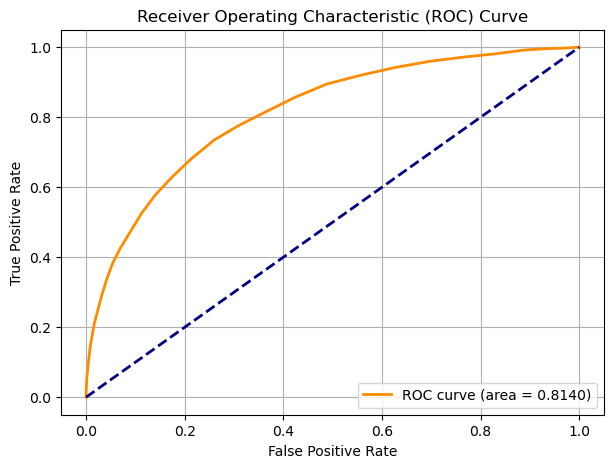

In [10]:
# Convert probabilities to binary outcomes using a 0.5 threshold

from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(random_state=42)
model.fit(X_train_full, y_train_full)

holdout_preds = model.predict_proba(X_holdout)[:, 1]   # probability of positive class
holdout_classes = (holdout_preds >= 0.5).astype(int)

print("Classification Report on Holdout Data:")
print(classification_report(y_holdout, holdout_classes))

# Plot ROC-AUC Curve
fpr, tpr, _ = roc_curve(y_holdout, holdout_preds)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_score(y_holdout, holdout_preds):.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()